In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

In [2]:
AQI_2015_2020 = pd.read_csv('/Users/aravindasv/Downloads/kaggle aqi/city_day.csv')

In [3]:
AQI_2015_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [4]:
AQI_2015_2020['City'].unique()

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

In [5]:
"""
Cities vs States
table generated in ChatGPT

| City               | State           |
| ------------------ | --------------- |
| Ahmedabad          | Gujarat         |
| Aizawl             | Mizoram         |
| Amaravati          | Andhra Pradesh  |
| Amritsar           | Punjab          |
| Bengaluru          | Karnataka       |
| Bhopal             | Madhya Pradesh  |
| Brajrajnagar       | Odisha          |
| Chandigarh         | Chandigarh (UT) |
| Chennai            | Tamil Nadu      |
| Coimbatore         | Tamil Nadu      |
| Delhi              | Delhi (NCT)     |
| Ernakulam          | Kerala          |
| Gurugram           | Haryana         |
| Guwahati           | Assam           |
| Hyderabad          | Telangana       |
| Jaipur             | Rajasthan       |
| Jorapokhar         | Jharkhand       |
| Kochi              | Kerala          |
| Kolkata            | West Bengal     |
| Lucknow            | Uttar Pradesh   |
| Mumbai             | Maharashtra     |
| Patna              | Bihar           |
| Shillong           | Meghalaya       |
| Talcher            | Odisha          |
| Thiruvananthapuram | Kerala          |
| Visakhapatnam      | Andhra Pradesh  |

"""

'\nCities vs States\ntable generated in ChatGPT\n\n| City               | State           |\n| ------------------ | --------------- |\n| Ahmedabad          | Gujarat         |\n| Aizawl             | Mizoram         |\n| Amaravati          | Andhra Pradesh  |\n| Amritsar           | Punjab          |\n| Bengaluru          | Karnataka       |\n| Bhopal             | Madhya Pradesh  |\n| Brajrajnagar       | Odisha          |\n| Chandigarh         | Chandigarh (UT) |\n| Chennai            | Tamil Nadu      |\n| Coimbatore         | Tamil Nadu      |\n| Delhi              | Delhi (NCT)     |\n| Ernakulam          | Kerala          |\n| Gurugram           | Haryana         |\n| Guwahati           | Assam           |\n| Hyderabad          | Telangana       |\n| Jaipur             | Rajasthan       |\n| Jorapokhar         | Jharkhand       |\n| Kochi              | Kerala          |\n| Kolkata            | West Bengal     |\n| Lucknow            | Uttar Pradesh   |\n| Mumbai             | Ma

In [6]:
# extract the yearly sheets separately. AQI_2015, AQI_2017

In [7]:
AQI_2015_2020['Date'].dtype

dtype('O')

In [24]:
# modify the column to DateTime
AQI_2015_2020['Date'] = pd.to_datetime(AQI_2015_2020['Date'])
AQI_2015 = AQI_2015_2020[AQI_2015_2020['Date'].dt.year == 2015]
AQI_2015.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [9]:
AQI_2015.shape

(2801, 16)

In [10]:
AQI_2015.isna().any(axis=1).sum()

np.int64(2487)

In [11]:
"""
this is a massive number of rows which have NaN values. but it could be because AQI, AQI_Bucket dont have the values
as we see in the first few rows
lets check what are the essential columns to calculate AQI
PM2.5, PM10, SO2, NOx, NH3, CO and O3
"""

'\nthis is a massive number of rows which have NaN values. but it could be because AQI, AQI_Bucket dont have the values\nas we see in the first few rows\nlets check what are the essential columns to calculate AQI\nPM2.5, PM10, SO2, NOx, NH3, CO and O3\n'

In [12]:
# credit: https://www.kaggle.com/willkoehrsen/start-here-a-gentle-introduction. 

def missing_values_table(df):
    # Total missing values
    mis_val = df.isnull().sum()
        
    # Percentage of missing values
    mis_val_percent = 100 * df.isnull().sum() / len(df)
        
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
    # Print some summary information
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
        "There are " + str(mis_val_table_ren_columns.shape[0]) + " columns that have missing values.")
        
    # Return the dataframe with missing information
    return mis_val_table_ren_columns

In [13]:
missing_values_table(AQI_2015)

Your selected dataframe has 16 columns.
There are 14 columns that have missing values.


,Missing Values,% of Total Values
PM10,2289,81.7
NH3,1614,57.6
Xylene,1465,52.3
AQI,974,34.8
AQI_Bucket,974,34.8
PM2.5,945,33.7
Benzene,627,22.4
Toluene,487,17.4
SO2,484,17.3
O3,461,16.5


In [25]:
AQI_2017 = AQI_2015_2020[AQI_2015_2020['Date'].dt.year == 2017]
AQI_2017.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
731,Ahmedabad,2017-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
732,Ahmedabad,2017-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
733,Ahmedabad,2017-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
734,Ahmedabad,2017-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
735,Ahmedabad,2017-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN


In [15]:
AQI_2017.shape

(4689, 16)

In [16]:
AQI_2015.isna().any(axis=1).sum()

np.int64(2487)

In [17]:
missing_values_table(AQI_2015)

Your selected dataframe has 16 columns.
There are 14 columns that have missing values.


,Missing Values,% of Total Values
PM10,2289,81.7
NH3,1614,57.6
Xylene,1465,52.3
AQI,974,34.8
AQI_Bucket,974,34.8
PM2.5,945,33.7
Benzene,627,22.4
Toluene,487,17.4
SO2,484,17.3
O3,461,16.5


In [18]:
missing_values_table(AQI_2017)

Your selected dataframe has 16 columns.
There are 14 columns that have missing values.


,Missing Values,% of Total Values
Xylene,2918,62.2
PM10,2662,56.8
NH3,2587,55.2
NOx,1940,41.4
AQI,1455,31.0
AQI_Bucket,1455,31.0
PM2.5,1395,29.8
O3,1384,29.5
SO2,1364,29.1
NO2,1266,27.0


In [ ]:
"""
there seems to be lot of missing values in some of the params. need to inspect and impute as required
but first, 
referring https://www.kaggle.com/code/rohanrao/calculating-aqi-air-quality-index-tutorial?scriptVersionId=41199538, the params we need to calculate AQI are - 
PM2.5, PM10, SO2, NOx, NH3, CO and O3
we can drop the rest columns except AQI, AQI_bucket
""" 

In [26]:
AQI_2015 = AQI_2015.drop(columns = ['Xylene','NO2','NO','Toluene','Benzene'])
AQI_2017 = AQI_2017.drop(columns = ['Xylene','NO2','NO','Toluene','Benzene'])

In [30]:
AQI_constituents = ['PM2.5', 'PM10', 'SO2', 'NOx', 'NH3', 'CO', 'O3']

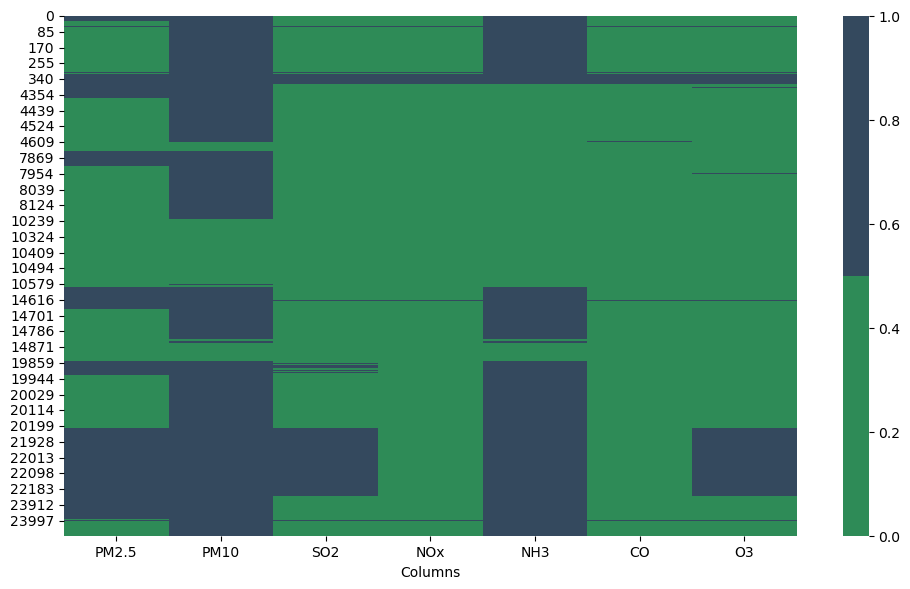

In [31]:
# lets pick the 2015 dataset first and deal with it
plt.figure(figsize=(10, 6))

colours = ['seagreen', '#34495E']   # green = observed, dark = missing
sns.heatmap(AQI_2015[AQI_constituents].isnull(), cmap=sns.color_palette(colours))

plt.xlabel('Columns')
plt.tight_layout()
plt.show()

In [ ]:
"""
there seems to be some pattern with the PM2.5 & O3 , PM10 & NH3
lets do heatmap and dendogram as well
from the above plot, it doesnt look like its MCAR. missing values are clearly at some blocks
it could be that some cities did not record or had faulty sensors
we will have to disect further based on cities and perform the action
lets see if some of the cities have more missing values
"""

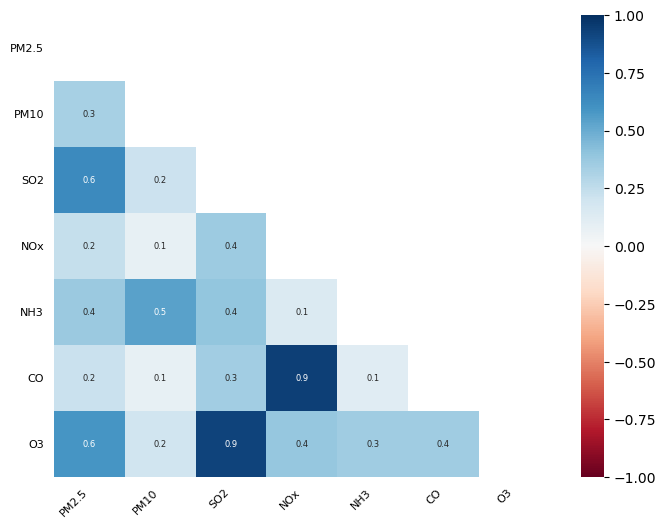

In [35]:
msno.heatmap(AQI_2015[AQI_constituents], figsize=(8,6), fontsize=8);

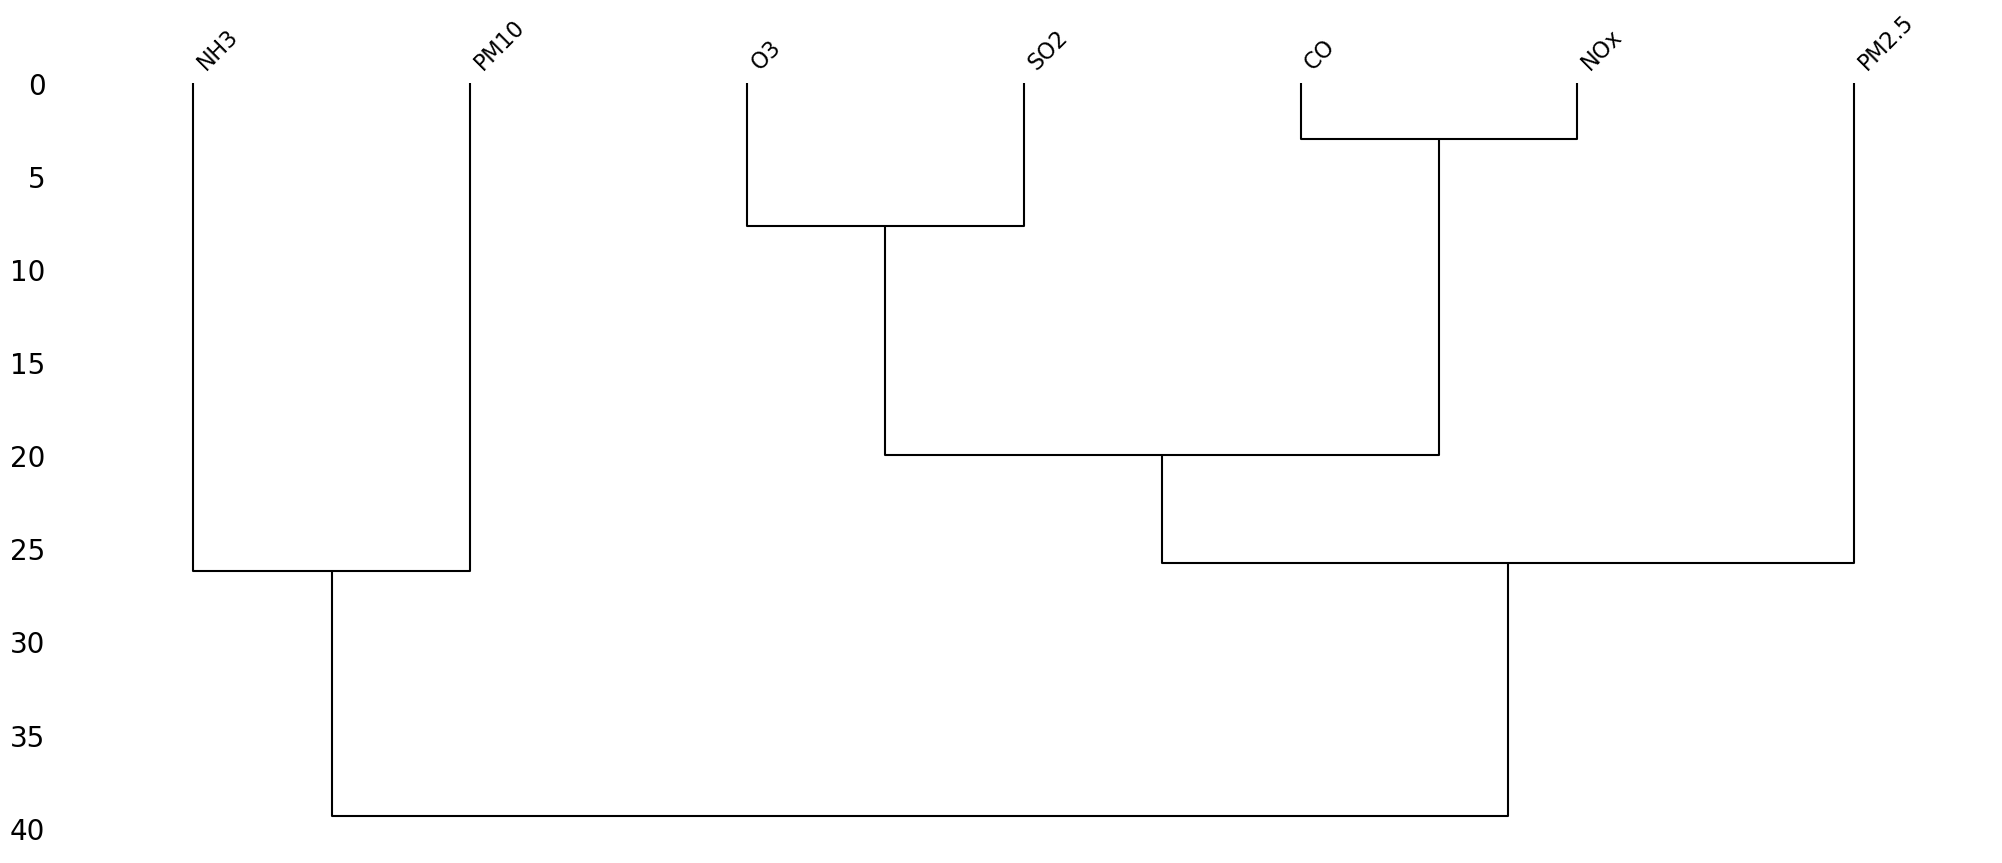

In [33]:
# columns which have missing value together cluster together
msno.dendrogram(AQI_2015[AQI_constituents]);

In [ ]:
"""
the above suggest that 03 and SO2 , CO and NOX, NH3 and PM10 are missing together
"""

In [68]:
AQI_2015['Month'] = pd.to_datetime(AQI_2015['Date']).dt.month

In [69]:
AQI_2015.groupby('City').apply(lambda x: x.isnull().all())

/var/folders/_5/y4j884ds52508czqk75s5n8w0000gn/T/ipykernel_2990/2551464250.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  AQI_2015.groupby('City').apply(lambda x: x.isnull().all())


,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Month
City,,,,,,,,,,,,
Ahmedabad,False,False,False,True,False,True,False,False,False,False,False,False
Bengaluru,False,False,False,False,False,False,False,False,False,False,False,False
Chennai,False,False,False,True,False,False,False,False,False,False,False,False
Delhi,False,False,False,False,False,False,False,False,False,False,False,False
Gurugram,False,False,True,True,False,True,False,False,False,True,True,False
Hyderabad,False,False,False,False,False,False,False,False,False,False,False,False
Lucknow,False,False,False,True,False,True,False,False,False,False,False,False
Mumbai,False,False,True,True,False,True,False,True,True,True,True,False
Patna,False,False,False,True,False,True,False,False,False,False,False,False


In [70]:
"""
cities and the indicators which are alwayas NaN
Mumbai → PM2.5, PM10, NH3, SO2, O3
Gurugram → PM2.5, NH3
Ahmedabad → NH3, SO2
Chennai → NH3
Lucknow → NH3, SO2
Patna → NH3, SO2

According to CPCB
minimum three pollutants out of which one should necessarily be either PM2.5 or PM10 is needed to calculate overall AQI

so we can remove Mumbai which has neither PM2.5 nor PM10
"""

'\ncities and the indicators which are alwayas NaN\nMumbai → PM2.5, PM10, NH3, SO2, O3\nGurugram → PM2.5, NH3\nAhmedabad → NH3, SO2\nChennai → NH3\nLucknow → NH3, SO2\nPatna → NH3, SO2\n\nAccording to CPCB\nminimum three pollutants out of which one should necessarily be either PM2.5 or PM10 is needed to calculate overall AQI\n\nso we can remove Mumbai which has neither PM2.5 nor PM10\n'

/var/folders/_5/y4j884ds52508czqk75s5n8w0000gn/T/ipykernel_2990/1462282524.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing = AQI_2015.groupby(['City', 'Month']).apply(lambda x: x.isnull().mean() * 100).mean(axis=1).unstack()


Text(0.5, 1.0, '% Missing Values by City and Month')

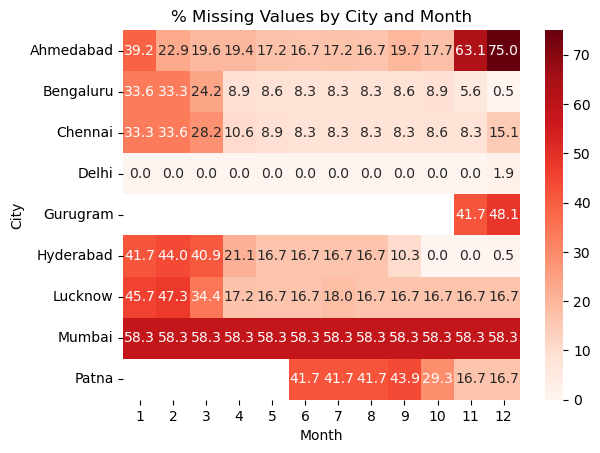

In [71]:
missing = AQI_2015.groupby(['City', 'Month']).apply(lambda x: x.isnull().mean() * 100).mean(axis=1).unstack()
sns.heatmap(missing, cmap='Reds', annot=True, fmt='.1f')
plt.title('% Missing Values by City and Month')

In [72]:
AQI_2015[AQI_2015['City']=='Gurugram']

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Month
12400,Gurugram,2015-11-27,NaN,NaN,9.57,NaN,2.88,15.92,5.96,NaN,NaN,11
12401,Gurugram,2015-11-28,NaN,NaN,9.74,NaN,0.47,5.78,8.13,NaN,NaN,11
12402,Gurugram,2015-11-29,NaN,NaN,8.69,NaN,1.67,5.26,16.52,NaN,NaN,11
12403,Gurugram,2015-11-30,NaN,NaN,9.54,NaN,1.45,7.51,6.29,NaN,NaN,11
12404,Gurugram,2015-12-01,NaN,NaN,8.86,NaN,1.45,3.72,10.50,NaN,NaN,12
12405,Gurugram,2015-12-02,NaN,NaN,11.20,NaN,2.08,6.99,10.10,NaN,NaN,12
12406,Gurugram,2015-12-03,NaN,NaN,14.32,NaN,0.66,2.69,8.75,NaN,NaN,12
12407,Gurugram,2015-12-04,NaN,NaN,13.94,NaN,3.91,14.63,16.09,NaN,NaN,12
12408,Gurugram,2015-12-05,NaN,NaN,14.28,NaN,2.09,9.10,19.52,NaN,NaN,12
12409,Gurugram,2015-12-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12


In [73]:
"""
we can ignore Gurugram, as there is only 1 month's AQI data captured for the whole year
moreover the data are mostly missing
"""

"\nwe can ignore Gurugram, as there is only 1 month's AQI data captured for the whole year\nmoreover the data are mostly missing\n"

In [78]:
patna = AQI_2015[AQI_2015['City']=='Patna']
patna

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Month
23864,Patna,2015-06-01,NaN,NaN,39.32,NaN,1.56,1.80,8.89,NaN,NaN,6
23865,Patna,2015-06-02,NaN,NaN,47.50,NaN,2.35,9.69,9.90,NaN,NaN,6
23866,Patna,2015-06-03,NaN,NaN,29.81,NaN,1.69,20.61,12.63,NaN,NaN,6
23867,Patna,2015-06-04,NaN,NaN,28.63,NaN,1.20,4.35,9.77,NaN,NaN,6
23868,Patna,2015-06-05,NaN,NaN,20.14,NaN,1.29,7.22,11.90,NaN,NaN,6
...,...,...,...,...,...,...,...,...,...,...,...,...
24073,Patna,2015-12-27,324.50,NaN,112.29,NaN,2.26,3.12,13.72,390.0,Very Poor,12
24074,Patna,2015-12-28,364.83,NaN,104.28,NaN,2.51,7.72,37.67,477.0,Severe,12
24075,Patna,2015-12-29,391.47,NaN,91.44,NaN,2.35,3.46,48.04,498.0,Severe,12
24076,Patna,2015-12-30,498.75,NaN,251.96,NaN,8.06,4.57,42.46,507.0,Severe,12


In [79]:
missing_values_table(patna)

Your selected dataframe has 12 columns.
There are 9 columns that have missing values.


,Missing Values,% of Total Values
PM10,214,100.0
NH3,214,100.0
AQI,133,62.1
AQI_Bucket,133,62.1
PM2.5,127,59.3
NOx,7,3.3
CO,7,3.3
SO2,7,3.3
O3,7,3.3


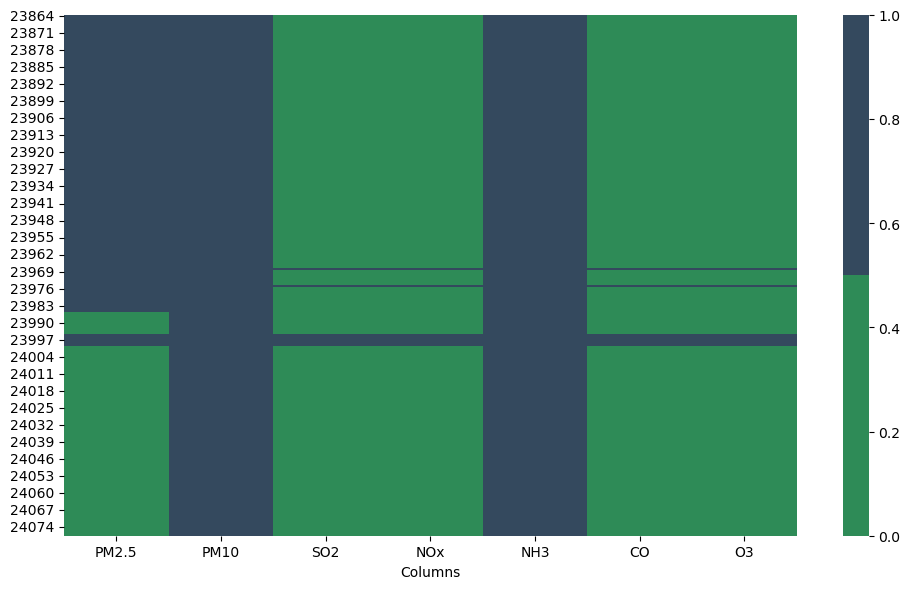

In [80]:
# Patna nullity heatmap
plt.figure(figsize=(10, 6))

colours = ['seagreen', '#34495E']   # green = observed, dark = missing
sns.heatmap(patna[AQI_constituents].isnull(), cmap=sns.color_palette(colours))

plt.xlabel('Columns')
plt.tight_layout()
plt.show()

In [81]:
# check how many rows we have where atleast PM2.5 or PM10 is not NaN
patna[patna['PM2.5'].notna() | patna['PM10'].notna()].shape[0]

87

In [82]:
patna[patna['PM2.5'].notna() | patna['PM10'].notna()]

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Month
23986,Patna,2015-10-01,100.96,NaN,74.68,NaN,1.30,4.65,7.82,NaN,NaN,10
23987,Patna,2015-10-02,71.20,NaN,55.98,NaN,2.44,4.93,9.04,NaN,NaN,10
23988,Patna,2015-10-03,74.28,NaN,45.62,NaN,1.04,4.79,6.25,154.0,Moderate,10
23989,Patna,2015-10-04,118.50,NaN,71.08,NaN,1.12,7.27,4.84,156.0,Moderate,10
23990,Patna,2015-10-05,99.12,NaN,79.26,NaN,1.63,4.48,6.12,222.0,Poor,10
...,...,...,...,...,...,...,...,...,...,...,...,...
24073,Patna,2015-12-27,324.50,NaN,112.29,NaN,2.26,3.12,13.72,390.0,Very Poor,12
24074,Patna,2015-12-28,364.83,NaN,104.28,NaN,2.51,7.72,37.67,477.0,Severe,12
24075,Patna,2015-12-29,391.47,NaN,91.44,NaN,2.35,3.46,48.04,498.0,Severe,12
24076,Patna,2015-12-30,498.75,NaN,251.96,NaN,8.06,4.57,42.46,507.0,Severe,12


In [ ]:
"""
87 would be nearly 3 months of data. which is 1/4th of the year
it starts from October. Just captures around one season
"""

In [75]:
# just to check that the plot aligns with the data for Delhi. it has all 365 days captured
AQI_2015[AQI_2015['City']=='Delhi']

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Month
10229,Delhi,2015-01-01,313.22,607.98,110.59,33.85,15.20,9.25,41.68,472.0,Severe,1
10230,Delhi,2015-01-02,186.18,269.55,88.14,31.83,9.54,6.65,29.97,454.0,Severe,1
10231,Delhi,2015-01-03,87.18,131.90,47.95,69.55,10.61,2.65,19.71,143.0,Moderate,1
10232,Delhi,2015-01-04,151.84,241.84,48.62,130.36,11.54,4.63,25.36,319.0,Very Poor,1
10233,Delhi,2015-01-05,146.60,219.13,38.25,122.88,9.20,3.33,23.20,325.0,Very Poor,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10589,Delhi,2015-12-27,187.01,375.13,99.66,72.76,11.30,21.41,98.88,370.0,Very Poor,12
10590,Delhi,2015-12-28,148.77,332.68,71.74,69.14,9.27,20.34,85.96,328.0,Very Poor,12
10591,Delhi,2015-12-29,159.67,325.05,82.43,60.62,2.32,21.23,82.69,331.0,Very Poor,12
10592,Delhi,2015-12-30,233.97,391.19,133.08,72.74,1.94,22.31,94.75,412.0,Severe,12


In [83]:
"""
remove Mumbai, Gurugram, Patna from the dataset
since they have insufficient data for the yearly summary of AQI
further remove the rows which have neither PM2.5 nor PM10
"""

In [87]:
cities_to_drop = ['Mumbai', 'Gurugram', 'Patna']
df_clean_2015 = AQI_2015[~AQI_2015['City'].isin(cities_to_drop)]
AQI_2015_with_sufficient_data = df_clean_2015[df_clean_2015['PM2.5'].notna() | df_clean_2015['PM10'].notna()]
AQI_2015_with_sufficient_data

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Month
27,Ahmedabad,2015-01-28,73.24,NaN,25.84,NaN,5.72,36.52,62.42,NaN,NaN,1
28,Ahmedabad,2015-01-29,83.13,NaN,33.72,NaN,6.93,49.52,59.76,209.0,Poor,1
29,Ahmedabad,2015-01-30,79.84,NaN,41.08,NaN,13.85,48.49,97.07,328.0,Very Poor,1
30,Ahmedabad,2015-01-31,94.52,NaN,52.61,NaN,24.39,67.39,111.33,514.0,Severe,1
31,Ahmedabad,2015-02-01,135.99,NaN,84.57,NaN,43.48,75.23,102.70,782.0,Severe,2
...,...,...,...,...,...,...,...,...,...,...,...,...
20206,Lucknow,2015-12-27,145.11,NaN,10.93,NaN,1.30,4.23,44.31,332.0,Very Poor,12
20207,Lucknow,2015-12-28,157.54,NaN,6.15,NaN,2.11,5.59,48.38,314.0,Very Poor,12
20208,Lucknow,2015-12-29,152.87,NaN,2.21,NaN,3.77,5.87,50.53,346.0,Very Poor,12
20209,Lucknow,2015-12-30,162.39,NaN,3.92,NaN,2.46,6.00,51.92,324.0,Very Poor,12


In [ ]:
"""
now lets continue the same process for 2017
"""

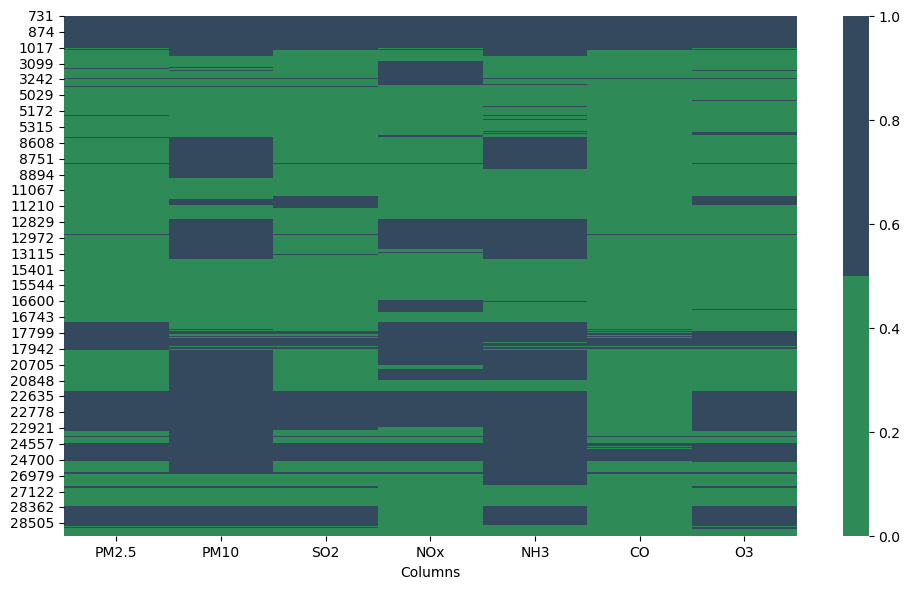

In [88]:
# lets pick the 2017 dataset first and deal with it
plt.figure(figsize=(10, 6))

colours = ['seagreen', '#34495E']   # green = observed, dark = missing
sns.heatmap(AQI_2017[AQI_constituents].isnull(), cmap=sns.color_palette(colours))

plt.xlabel('Columns')
plt.tight_layout()
plt.show()

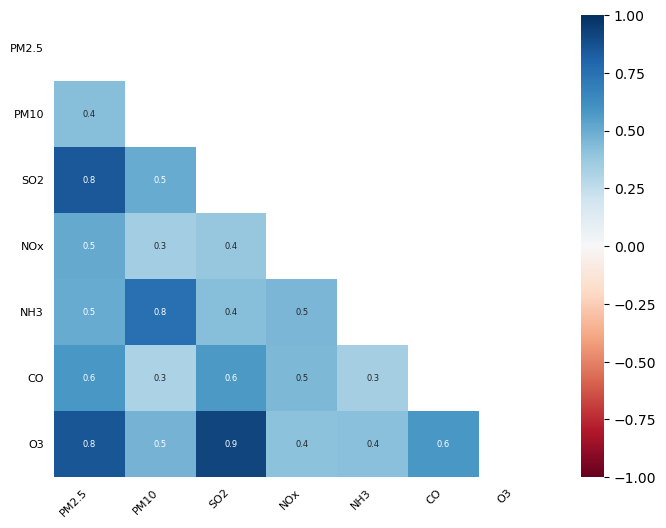

In [90]:
msno.heatmap(AQI_2017[AQI_constituents], figsize=(8,6), fontsize=8);

In [93]:
AQI_2017['Month'] = pd.to_datetime(AQI_2017['Date']).dt.month

In [95]:
AQI_2017.groupby('City').apply(lambda x: x.isnull().all())

/var/folders/_5/y4j884ds52508czqk75s5n8w0000gn/T/ipykernel_2990/3196169101.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  AQI_2017.groupby('City').apply(lambda x: x.isnull().all())


,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Month
City,,,,,,,,,,,,
Ahmedabad,False,False,False,True,False,True,False,False,False,False,False,False
Amaravati,False,False,False,False,False,False,False,False,False,False,False,False
Amritsar,False,False,False,False,False,False,False,False,False,False,False,False
Bengaluru,False,False,False,False,False,False,False,False,False,False,False,False
Brajrajnagar,False,False,False,False,False,False,False,False,False,False,False,False
Chennai,False,False,False,True,False,False,False,False,False,False,False,False
Delhi,False,False,False,False,False,False,False,False,False,False,False,False
Gurugram,False,False,False,False,False,True,False,False,False,False,False,False
Hyderabad,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
"""
Jorapokhar → PM2.5, NOx always null
Talcher → PM2.5, PM10, NOx, NH3, CO, SO2 always null
Mumbai → PM2.5, PM10, NH3, SO2 always null

we can drop Talcher and Mumbai
"""

/var/folders/_5/y4j884ds52508czqk75s5n8w0000gn/T/ipykernel_2990/3784712710.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing = AQI_2017.groupby(['City', 'Month']).apply(lambda x: x.isnull().mean() * 100).mean(axis=1).unstack()


Text(0.5, 1.0, '% Missing Values by City and Month')

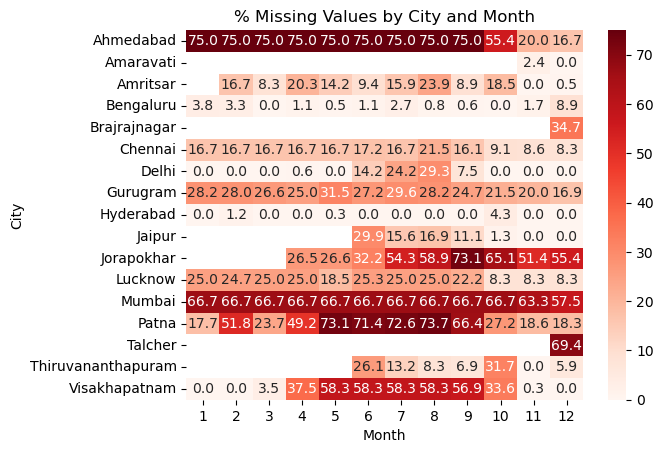

In [96]:
missing = AQI_2017.groupby(['City', 'Month']).apply(lambda x: x.isnull().mean() * 100).mean(axis=1).unstack()
sns.heatmap(missing, cmap='Reds', annot=True, fmt='.1f')
plt.title('% Missing Values by City and Month')

In [ ]:
"""
we can remove Amaravati, Brajrajnagar without doubt
but need further inspection on Jaipur & Thiruvananthapuram
"""

In [97]:
jaipur = AQI_2017[AQI_2017['City']=='Jaipur']
jaipur

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Month
16587,Jaipur,2017-06-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
16588,Jaipur,2017-06-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
16589,Jaipur,2017-06-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
16590,Jaipur,2017-06-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
16591,Jaipur,2017-06-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
...,...,...,...,...,...,...,...,...,...,...,...,...
16783,Jaipur,2017-12-27,75.44,194.31,15.77,61.28,0.0,11.31,42.85,194.0,Moderate,12
16784,Jaipur,2017-12-28,102.64,173.48,31.67,7.12,0.0,7.65,38.57,227.0,Poor,12
16785,Jaipur,2017-12-29,65.88,169.41,44.81,13.34,0.0,11.57,54.47,148.0,Moderate,12
16786,Jaipur,2017-12-30,68.64,203.76,27.74,18.14,0.0,17.52,70.86,174.0,Moderate,12


In [98]:
# checking how many rows have either PM2.5 or PM10
jaipur[jaipur['PM2.5'].notna() | jaipur['PM10'].notna()].shape[0]

189

In [102]:
thiruvananthapuram = AQI_2017[AQI_2017['City']=='Thiruvananthapuram']
thiruvananthapuram[thiruvananthapuram['PM2.5'].notna() | thiruvananthapuram['PM10'].notna()].shape[0]

177

In [103]:
thiruvananthapuram[thiruvananthapuram['PM2.5'].notna() | thiruvananthapuram['PM10'].notna()]

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Month
26957,Thiruvananthapuram,2017-06-16,38.00,10.00,6.20,NaN,0.71,4.10,18.30,NaN,NaN,6
26960,Thiruvananthapuram,2017-06-19,24.00,36.00,3.30,NaN,0.73,4.50,19.10,NaN,NaN,6
26962,Thiruvananthapuram,2017-06-21,24.00,36.00,3.30,NaN,0.73,4.50,19.10,NaN,NaN,6
26963,Thiruvananthapuram,2017-06-22,16.25,37.12,6.17,NaN,0.84,3.47,15.48,NaN,NaN,6
26964,Thiruvananthapuram,2017-06-23,15.08,31.09,4.65,NaN,0.71,4.65,17.54,47.0,Good,6
...,...,...,...,...,...,...,...,...,...,...,...,...
27151,Thiruvananthapuram,2017-12-27,64.68,86.73,6.49,10.06,1.38,3.89,41.20,103.0,Moderate,12
27152,Thiruvananthapuram,2017-12-28,72.44,98.85,6.41,9.19,1.36,3.89,39.10,129.0,Moderate,12
27153,Thiruvananthapuram,2017-12-29,61.44,85.70,7.53,9.12,1.20,3.38,29.28,112.0,Moderate,12
27154,Thiruvananthapuram,2017-12-30,73.02,100.61,7.23,10.60,1.42,4.14,41.68,145.0,Moderate,12


In [104]:
cities_to_drop_2017 = ['Talcher','Mumbai','Amaravati','Brajrajnagar']
df_clean_2017 = AQI_2017[~AQI_2017['City'].isin(cities_to_drop_2017)]
AQI_2017_with_sufficient_data = df_clean_2017[df_clean_2017['PM2.5'].notna() | df_clean_2017['PM10'].notna()]
AQI_2017_with_sufficient_data

,City,Date,PM2.5,PM10,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket,Month
1013,Ahmedabad,2017-10-10,64.55,NaN,45.75,NaN,NaN,NaN,17.70,NaN,NaN,10
1014,Ahmedabad,2017-10-11,61.72,NaN,36.60,NaN,NaN,NaN,9.73,105.0,Moderate,10
1021,Ahmedabad,2017-10-18,76.32,NaN,75.00,NaN,NaN,NaN,NaN,NaN,NaN,10
1023,Ahmedabad,2017-10-20,109.16,NaN,76.30,NaN,NaN,NaN,40.28,NaN,NaN,10
1024,Ahmedabad,2017-10-21,126.57,NaN,46.52,NaN,NaN,NaN,27.85,319.0,Very Poor,10
...,...,...,...,...,...,...,...,...,...,...,...,...
28613,Visakhapatnam,2017-12-27,101.93,176.88,42.58,14.37,1.20,16.39,69.82,290.0,Poor,12
28614,Visakhapatnam,2017-12-28,88.29,195.79,55.30,11.48,1.28,16.54,57.78,203.0,Poor,12
28615,Visakhapatnam,2017-12-29,52.25,103.40,35.20,11.33,1.08,6.26,52.57,160.0,Moderate,12
28616,Visakhapatnam,2017-12-30,58.56,100.61,19.08,12.22,0.93,5.44,80.89,99.0,Satisfactory,12


In [108]:
AQI_2017_with_sufficient_data[['City']].nunique()

City    13
dtype: int64